In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sanaurooj/Library/Python/3.12/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sanaurooj/Library/Python/3.12/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/sanaurooj/Library/Python/3.12/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_lo

In [20]:
from sklearn.model_selection import train_test_split
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [50]:
torch.manual_seed(42)

In [51]:
df = pd.read_csv('fmnist_small.csv')

In [52]:
df.shape

(6000, 785)

In [53]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


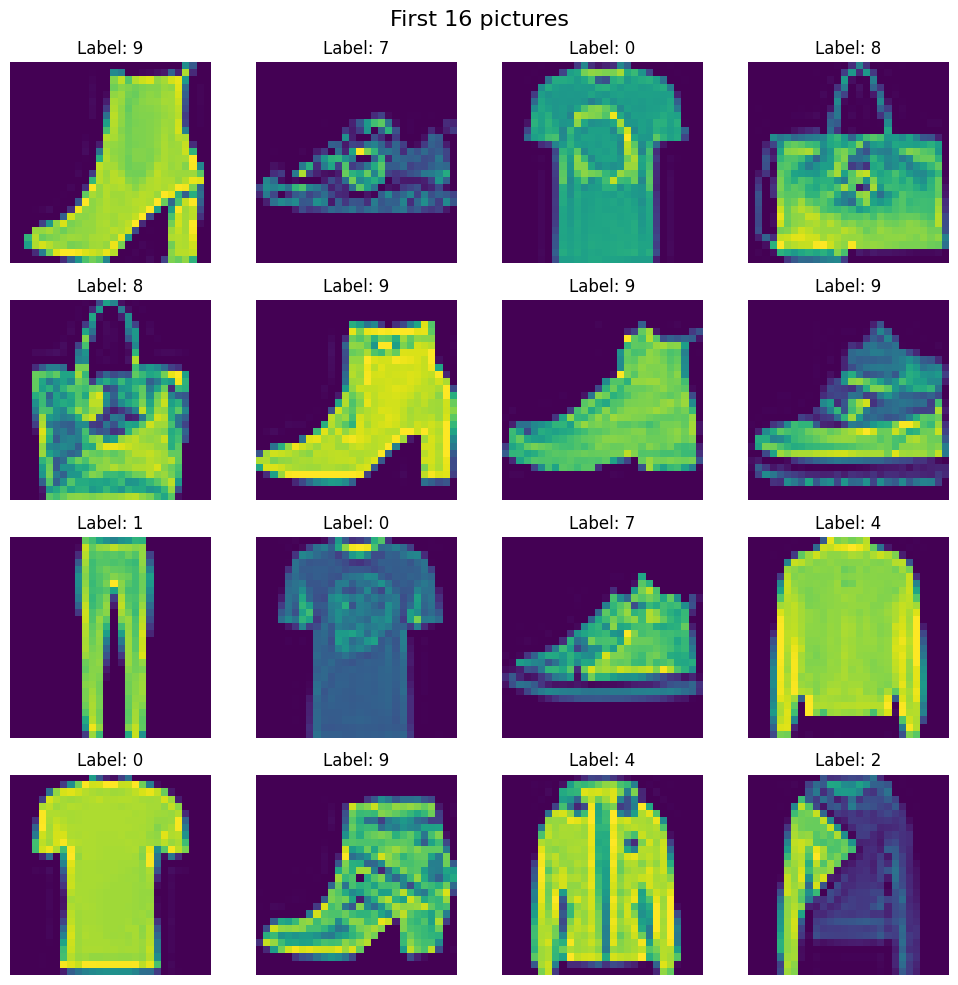

In [54]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle('First 16 pictures', fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout()
plt.show()

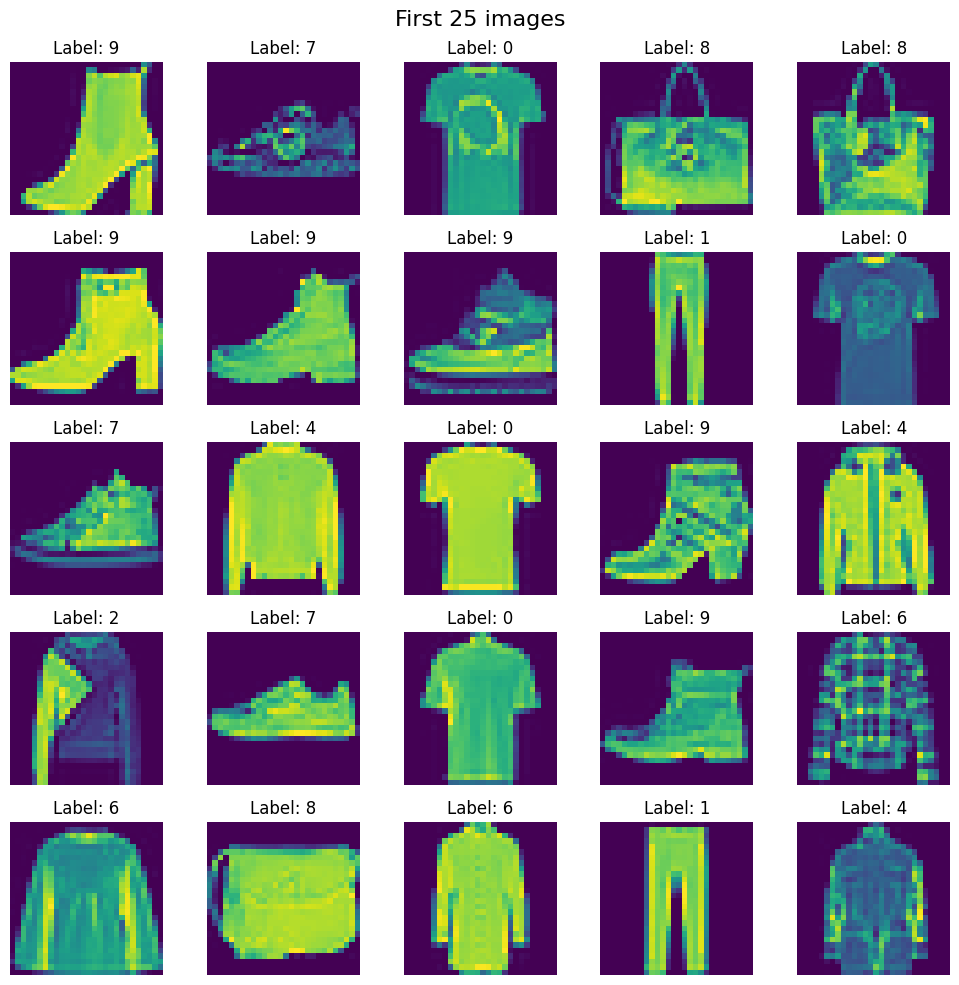

In [55]:
fig, axes = plt.subplots(5,5, figsize=(10,10))
fig.suptitle('First 25 images', fontsize=16)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Label: {df.iloc[i,0]}')

plt.tight_layout()
plt.show()

In [56]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [57]:
X.shape, X.ndim, y.shape, y.ndim

((6000, 784), 2, (6000,), 1)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
X_train

array([[ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ..., 16,  0,  0]], shape=(4800, 784))

In [60]:
X_train = X_train/255.0
X_test = X_test/255.0

In [61]:
#custom dataset 
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [62]:
train_dataset = CustomDataset(X_train, y_train)

In [63]:
test_dataset = CustomDataset(X_test, y_test)

In [64]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle=False)

In [65]:
# My NN
class myNN(nn.Module):
    
    def __init__(self, num_of_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_of_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)

In [71]:
epochs = 200
learning_rate = 0.1

In [72]:
model = myNN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [73]:
# learning loop

for epoch in range(epochs):
    total_loss = 0
    for batch_features, batch_labels in train_loader:

        predictions = model(batch_features)

        loss = criterion(predictions, batch_labels)
        total_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    avg_loss = total_loss/len(batch_features)
    if (epoch+1)%10==0:
        print(f"Epoch: {epoch+1} | Loss: {avg_loss}")

Epoch: 10 | Loss: 1.9373363256454468
Epoch: 20 | Loss: 1.268568992614746
Epoch: 30 | Loss: 0.950267493724823
Epoch: 40 | Loss: 0.6455995440483093
Epoch: 50 | Loss: 0.5408847332000732
Epoch: 60 | Loss: 0.411986380815506
Epoch: 70 | Loss: 0.19298797845840454
Epoch: 80 | Loss: 0.24511712789535522
Epoch: 90 | Loss: 0.10060637444257736
Epoch: 100 | Loss: 0.06939275562763214
Epoch: 110 | Loss: 0.009433528408408165
Epoch: 120 | Loss: 0.005802866071462631
Epoch: 130 | Loss: 0.004365995991975069
Epoch: 140 | Loss: 0.0034849997609853745
Epoch: 150 | Loss: 0.002921629697084427
Epoch: 160 | Loss: 0.0025275712832808495
Epoch: 170 | Loss: 0.002194853499531746
Epoch: 180 | Loss: 0.0019716033712029457
Epoch: 190 | Loss: 0.001762819942086935
Epoch: 200 | Loss: 0.001602823962457478


In [74]:
total = 0
correct = 0

model.eval()
with torch.inference_mode():
     for test_features, test_labels in test_loader:
          
        output = model(test_features)
        _,predicted = torch.max(output,1)

        total += test_features.shape[0]

        correct += (predicted== test_labels).sum().item()

print(correct/total*100)




84.58333333333333
